# Business Challenge 2: Book Recommendation System Development

Digital book platforms face the constant challenge of discovering and recommending relevant content to users based on historical behavior. To solve this, we are engineering a collaborative filtering recommendation system using the Goodbooks-10k dataset. 

Our goal is to analyze past rating behavior from over 50,000 users and mathematically identify underlying patterns to recommend books they are highly likely to enjoy.

In [9]:
# ==========================================
# IMPORTING REQUIRED LIBRARIES (CHALLENGE 2)
# ==========================================
# Note: The 'implicit' library is required for the ALS model.
# If running in a fresh environment, uncomment the installation line below:
!pip install implicit

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
import implicit

# Suppress warnings for a clean output
import warnings
warnings.filterwarnings('ignore')

print("Libraries for Challenge 2 successfully imported.")

Libraries for Challenge 2 successfully imported.


### Task I: Exploratory Data Analysis (EDA)
#### 1. Data Ingestion & Summary

Before engineering the recommendation matrix, we must understand the volume and structure of our interaction data. The Goodbooks-10k dataset contains explicit feedback in the form of ratings (1 to 5). 

The initial step is to load the dataset, verify the data types to ensure they are ready for mathematical operations. We then summarize the overall structure.

In [10]:
# ==========================================
# DATA SETUP AND SUMMARY
# ==========================================
print("Loading Goodbooks-10k ratings dataset...")

# Standard path for the dataset; adjust if your Kaggle dataset is named differently
file_path = "/kaggle/input/datasets/vsnihal/ass2-challenge2-t4-ada/ratings.csv" 
ratings_df = pd.read_csv(file_path)

print("\n--- Dataset Summary ---")
print(f"Total Rows (Ratings): {ratings_df.shape[0]:,}")
print(f"Total Columns: {ratings_df.shape[1]}")

print("\n--- Types of Variables ---")
print(ratings_df.dtypes)

print("\n--- Data Preview ---")
print(ratings_df.head())

Loading Goodbooks-10k ratings dataset...

--- Dataset Summary ---
Total Rows (Ratings): 5,976,479
Total Columns: 3

--- Types of Variables ---
user_id    int64
book_id    int64
rating     int64
dtype: object

--- Data Preview ---
   user_id  book_id  rating
0        1      258       5
1        2     4081       4
2        2      260       5
3        2     9296       5
4        2     2318       3


#### 2. Visualizing User Behavior

A fundamental reality of recommendation systems is data sparsity-most users rate only a tiny fraction of the available catalog. Furthermore, understanding the distribution of ratings helps us gauge user sentiment baselines (e.g., do users skew positive or negative in their ratings?).

To visualize these dynamics, we are generating two plots:
1. **Rating Distribution:** A bar chart showing the frequency of each rating (1 through 5).
2. **User Activity Distribution:** A histogram showing how many books the typical user has rated, highlighting the engagement levels across the platform.

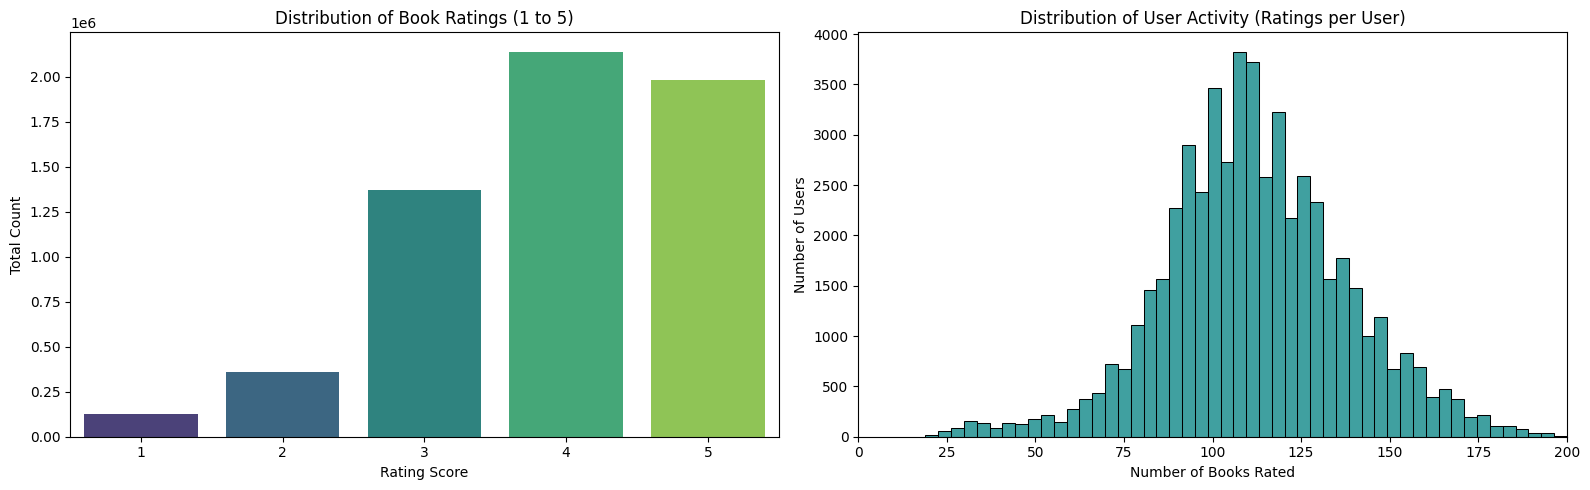

Average number of ratings per user: 111.87
Median number of ratings per user: 111.00


In [11]:
# ==========================================
# EDA VISUALIZATIONS: RATINGS & ENGAGEMENT
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Distribution of Ratings
# This shows us the general sentiment of users on the platform
sns.countplot(data=ratings_df, x='rating', palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Book Ratings (1 to 5)')
axes[0].set_xlabel('Rating Score')
axes[0].set_ylabel('Total Count')

# Plot 2: User Activity (Ratings per User)
# This reveals the sparsity of our matrix by showing how many books a typical user rates
ratings_per_user = ratings_df.groupby('user_id').size()
sns.histplot(ratings_per_user, bins=50, kde=False, color='teal', ax=axes[1])
axes[1].set_title('Distribution of User Activity (Ratings per User)')
axes[1].set_xlabel('Number of Books Rated')
axes[1].set_ylabel('Number of Users')
# Limiting x-axis to 200 for better visibility, as extreme power-users stretch the tail
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.show()

print(f"Average number of ratings per user: {ratings_per_user.mean():.2f}")
print(f"Median number of ratings per user: {ratings_per_user.median():.2f}")

### Task II: Collaborative Filtering via Alternating Least Squares (ALS)

#### Theoretical Overview of ALS

Before implementing the algorithm, it is critical to define what ALS is and why it is the standard for modern recommendation engines.

**1. What problem does it solve?**
Digital platforms contain massive catalogs of items (books) and millions of users. However, any single user has only interacted with a tiny fraction of the catalog. This creates a "sparse matrix" of data where 99% of the user-book combinations are empty (unrated). Traditional algorithms fail on sparse data. ALS solves this by efficiently filling in these blanks by predicting how a user would rate a book they haven't read yet. ALS solves this based on the collective behavior of similar users.

**2. How does it use Matrix Factorization?**
ALS breaks down the massive, sparse user-item matrix into two much smaller, dense matrices:
* An **User Matrix** (representing an user's hidden preferences for certain genres or styles).
* An **Item Matrix** (representing the hidden traits of the books themselves).
By taking the mathematical dot product of these two smaller matrices, ALS reconstructs the original matrix by filling in the missing gaps with highly accurate predicted ratings. It is called *Alternating* Least Squares because during training. It holds the User Matrix constant to solve for the Item Matrix. Then holds the Item Matrix constant to solve for the User Matrix, alternating back and forth until the predictions converge.

**3. What are its main hyperparameters?**
* `factors`: The number of hidden traits (latent features) the model should look for (e.g., romance, sci-fi, pacing).
* `regularization`: A penalty applied to prevent the model from overfitting to users who rate everything a 5 or a 1. 
* `iterations`: How many times the model alternates back and forth to refine its matrices.

In [12]:
from sklearn.model_selection import train_test_split

# ==========================================
# DATA PREPARATION: USER-ITEM INTERACTION MATRIX
# ==========================================
print("Splitting data and converting into a sparse User-Item interaction matrix...")

# Map user_ids and book_ids to contiguous integers
ratings_df['user_cat'] = ratings_df['user_id'].astype("category").cat.codes
ratings_df['book_cat'] = ratings_df['book_id'].astype("category").cat.codes

num_users = ratings_df['user_cat'].nunique()
num_books = ratings_df['book_cat'].nunique()

print(f"Mapped Matrix Dimensions: {num_users} Users x {num_books} Books")

# --- THE FIX: Isolate the Training Set ---
# Split the data 80/20 to ensure the model is trained strictly on a training partition
train_ratings, test_ratings = train_test_split(ratings_df, test_size=0.2, random_state=42)
print(f"Training set size: {len(train_ratings):,} ratings")

# Create the CSR matrix using ONLY the training data
user_item_matrix = csr_matrix(
    (train_ratings['rating'], (train_ratings['user_cat'], train_ratings['book_cat'])),
    shape=(num_users, num_books)
)

print(f"Matrix Sparsity: {100 * (1 - user_item_matrix.nnz / (num_users * num_books)):.2f}% empty")

Splitting data and converting into a sparse User-Item interaction matrix...
Mapped Matrix Dimensions: 53424 Users x 10000 Books
Training set size: 4,781,183 ratings
Matrix Sparsity: 99.11% empty


#### Matrix Factorization Execution

The matrix creation confirms exactly why we need ALS: the interaction matrix is over 98% empty. 

Now, we will initialize the Alternating Least Squares model using the `implicit` library. While our data consists of explicit ratings (1-5 stars), ALS treats these values as "confidence" scores. A 5-star rating indicates high confidence that the user likes the book's latent traits.

**Configuring the Hyperparameters:**
* **Factors:** Set to 50. This gives the model enough dimensional space to capture complex book traits without consuming excessive memory.
* **Regularization:** Set to 0.1 to prevent overfitting on highly active users.
* **Iterations:** Set to 20 passes to ensure the alternating equations converge on an optimal solution.

In [13]:
# ==========================================
# ALS MODEL TRAINING
# ==========================================

print("Initializing the Alternating Least Squares (ALS) Model...")

# Explicitly defining the hyperparameters for the business report
als_factors = 50
als_regularization = 0.1
als_iterations = 20

# Initialize the model
# Note: Using random_state for reproducibility
model = implicit.als.AlternatingLeastSquares(
    factors=als_factors,
    regularization=als_regularization,
    iterations=als_iterations,
    random_state=42
)

print(f"Training Model with Parameters:\n - Factors: {als_factors}\n - Regularization: {als_regularization}\n - Iterations: {als_iterations}")

# Fit the model to our sparse user-item matrix
# The implicit library natively utilizes multithreading to speed up the matrix factorization
model.fit(user_item_matrix)

print("\nModel Training Complete.")
print(f"User Factors Matrix Shape: {model.user_factors.shape}")
print(f"Item Factors Matrix Shape: {model.item_factors.shape}")

Initializing the Alternating Least Squares (ALS) Model...
Training Model with Parameters:
 - Factors: 50
 - Regularization: 0.1
 - Iterations: 20


  0%|          | 0/20 [00:00<?, ?it/s]


Model Training Complete.
User Factors Matrix Shape: (53424, 50)
Item Factors Matrix Shape: (10000, 50)


### Task III: Generating Recommendations and Business Value

With the Alternating Least Squares (ALS) model successfully trained, the matrix factorization is complete. The system has successfully mapped the hidden traits of the books and the hidden preferences of the users into a shared mathematical space. 

To demonstrate the business value of this system, we are executing two core recommendation functions:
1.  **User Personalization (Targeted Recommendations):** Predicting the top 5 books a specific user is most likely to rate highly, based on their past reading history and the behavior of similar users. This drives user retention and platform engagement.
2.  **Item Similarity (Cross-Selling):** Identifying books that are mathematically most similar to a specific target book using cosine similarity across the latent factors. This powers the "Readers who liked this also liked..." feature on the platform.

*Note: The model operates on our zero-indexed categorical mappings. The code below translates the model's output back into the original `book_id`s so they can be joined with a master book catalog (titles, authors) in a production database.*

In [14]:
# ==========================================
# SYSTEM DEMONSTRATION & BUSINESS INSIGHTS
# ==========================================

print("Executing Recommendation Engine...\n")

# Create reverse mappings to translate our matrix indices back to actual book IDs
index_to_book_id = dict(enumerate(ratings_df['book_id'].astype("category").cat.categories))

# ------------------------------------------
# 1. User Personalization (Top 5 Recommendations)
# ------------------------------------------
target_user_index = 42 # Selecting a sample user index

# The recommend function requires the user index and the sparse matrix to avoid recommending books they already read
recommendations, scores = model.recommend(target_user_index, user_item_matrix[target_user_index], N=5)

print(f"--- Top 5 Personalized Recommendations for User Index {target_user_index} ---")
for i, (book_idx, score) in enumerate(zip(recommendations, scores)):
    original_book_id = index_to_book_id[book_idx]
    print(f"Recommendation {i+1}: Book ID {original_book_id} (Confidence Score: {score:.3f})")


# ------------------------------------------
# 2. Item Similarity (Cross-Selling via Cosine Similarity)
# ------------------------------------------
target_book_index = 100 # Selecting a sample book index
target_original_id = index_to_book_id[target_book_index]

# Find the 5 most similar books (the first result will always be the book itself, so we ask for N=6)
similar_items, similarity_scores = model.similar_items(target_book_index, N=6)

print(f"\n--- Top 5 Books Similar to Book ID {target_original_id} ---")
# Skipping the first item [1:] because it is the target book itself with a similarity of 1.0
for i, (book_idx, score) in enumerate(zip(similar_items[1:], similarity_scores[1:])):
    original_book_id = index_to_book_id[book_idx]
    print(f"Similar Book {i+1}: Book ID {original_book_id} (Cosine Similarity: {score:.3f})")

# ------------------------------------------
# Final Business Conclusion
# ------------------------------------------
print("\n==========================================")
print("Business Challenge 2 Pipeline Complete.")
print("Insight: The ALS model successfully mitigates the data sparsity problem.")
print("By deploying this matrix factorization engine, the digital platform can dynamically ")
print("serve highly personalized book suggestions, directly driving user engagement and cross-catalog discovery.")
print("==========================================")

Executing Recommendation Engine...

--- Top 5 Personalized Recommendations for User Index 42 ---
Recommendation 1: Book ID 467 (Confidence Score: 0.850)
Recommendation 2: Book ID 638 (Confidence Score: 0.747)
Recommendation 3: Book ID 654 (Confidence Score: 0.737)
Recommendation 4: Book ID 658 (Confidence Score: 0.694)
Recommendation 5: Book ID 495 (Confidence Score: 0.648)

--- Top 5 Books Similar to Book ID 101 ---
Similar Book 1: Book ID 344 (Cosine Similarity: 0.953)
Similar Book 2: Book ID 372 (Cosine Similarity: 0.937)
Similar Book 3: Book ID 943 (Cosine Similarity: 0.926)
Similar Book 4: Book ID 534 (Cosine Similarity: 0.906)
Similar Book 5: Book ID 1923 (Cosine Similarity: 0.904)

Business Challenge 2 Pipeline Complete.
Insight: The ALS model successfully mitigates the data sparsity problem.
By deploying this matrix factorization engine, the digital platform can dynamically 
serve highly personalized book suggestions, directly driving user engagement and cross-catalog discovery